In [1]:
!hostname

node114


In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Get participant data for current pipeline

In [21]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_meta_dict(meta_file_name):
    part_manifest = pd.read_pickle(meta_file_name)
    records = []
    trial_ix_count = 0 
    for block_name, block in part_manifest.items():
        if isinstance(block, dict):
            for trial_ix, trial_dict in block.items():
                trial_dict['trial_num'] = trial_ix_count
                trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
                trial_dict['target_elev'] = trial_dict['target_loc'][1]
                trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
                trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
                trial_dict['block_name'] = block_name
                records.append(trial_dict)
                trial_ix_count += 1

        elif isinstance(block, list):
            for trial in block:
                trial['target_azimuth'] = trial['target_loc'][0]
                trial['target_elev'] = trial['target_loc'][1]
                trial['distractor_azimuth'] = trial['distractor_loc'][0]
                trial['distractor_elev'] = trial['distractor_loc'][1]
                trial['block_name'] = block_name
                trial['cue_fn'] = Path(trial['cue_fn'][0]).stem
                trial['target_fn'] = Path(trial['target_fn'][0]).stem
                trial['distractor_fn'] = Path(trial['distractor_fn'][0]).stem
                records.append(trial)
    

    meta_df = pd.DataFrame(records)
    meta_df.drop(columns=['target_loc', 'distractor_loc'], inplace=True)
    if 'global_trial_ix' in meta_df.columns:
        meta_df.rename(columns={'global_trial_ix': 'trial_num'}, inplace=True)
    return meta_df

def get_part_manifest(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    for ix, trial_manifest in enumerate(part_manifest):
        trial_dict = {}
        trial_dict['trial_num'] = ix
        # trial_dict['target_azimuth'] = trial_manifest[0][0]
        # trial_dict['target_elev'] = trial_manifest[0][1]
        # trial_dict['distractor_azimuth'] = trial_manifest[1][0]
        # trial_dict['distractor_elev'] = trial_manifest[1][1]
        # trial_dict['snr'] = trial_manifest[2]
        trial_dict['cue_fn'] = Path(trial_manifest[3][0]).stem
        trial_dict['target_fn'] = Path(trial_manifest[4][0]).stem
        trial_dict['distractor_fn'] = Path(trial_manifest[5][0]).stem

        records.append(trial_dict)
    manifest_df = pd.DataFrame(records)
    return manifest_df

In [22]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
manifest_files = sorted(list(Path(exp_manifest_path).glob('*manifest.pkl')))

result_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v01/'
exp_manifest_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v01/'
part_results += sorted(list(Path(result_path_v1).glob('*.csv')))
meta_files += sorted(list(Path(exp_manifest_path_v1).glob('*meta.pkl')))
manifest_files += sorted(list(Path(exp_manifest_path_v1).glob('*manifest.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
meta_dict = {}

for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    if 'v01' in meta_file.parent.stem:
        part_name += '_v01'
    meta_dict[part_name] = meta_file

for manifest_file in manifest_files:
    if 'pilot' in manifest_file.parent.stem:
        part_name = "pilot_" + "_".join(manifest_file.stem.split('_')[:2])

    else:
        part_name = "_".join(manifest_file.stem.split('_')[:2])
    if 'v01' in manifest_file.parent.stem:
        part_name += '_v01'
    manifest_dict[part_name] = manifest_file

block_name_map = {
    'target_0': "block_front",
    'target_40': "block_fourty",
    'target_90': "block_ninety",
}

dfs = []
for result_file in part_results:
    part_name = result_file.stem
    # print(part_name)
    # remove space 
    if '000' in part_name:
        continue
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    if 'test' not in part_name: 
        part_ix = int(re.search(r'\d+', part_name).group())
        part_name_str = f"participant_{part_ix:03d}"
    if 'test' in part_name:
        continue
    if 'v01' in result_file.parent.stem:
        part_name_str += '_v01'

    meta_file = meta_dict[part_name_str]
    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    meta_df = get_part_meta_dict(meta_file)
    manifest_df = get_part_manifest(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            meta_df, left_on='trial_num', right_on='trial_num',)
    if 'cue_fn' not in part_df.columns:
        part_df = pd.merge(part_df, manifest_df, left_on='trial_num', right_on='trial_num')
    part_df['participant'] = part_name_str
    if part_df.block_name.str.contains('target').any():
        part_df['block_name'] = [block_name_map['_'.join(block.split('_')[:2])] for block in part_df.block_name]
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
results_df['dist_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.target_fn.to_list()]


cols_to_score = ['response', 'target_word', 'distractor_word', 'target_transcripts', 'dist_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_word, target_transcripts, dist_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_transcripts or response == distractor_word))

results_df['correct'] = correct
results_df['confusions'] = confusions

In [23]:
results_df

,trial_num,response,correct_response,correct,azim_delta,elev_delta,snr,target_word,distractor_word,target_azimuth,...,block_name,cue_fn,target_fn,distractor_fn,participant,block_ix,abs_target_azim,dist_transcripts,target_transcripts,confusions
0,0,being,current,0,0,0,0,current,b,0,...,block_front,full_df_ix_0588_standard-nicholasturnbull,full_df_ix_0588_current-nicholasturnbull,full_df_ix_0588_being-demi_eg_0,participant_001,NaN,0,"[that, a, supreme, being, directly, creates]","[was, a, supporter, of, current, president, joe]",1
1,1,close,looked,0,10,0,0,looked,s,0,...,block_front,full_df_ix_0720_taking-dmitry-brant,full_df_ix_0720_looked-dmitry-brant,full_df_ix_0720_system-zanimum_eg_0,participant_001,NaN,0,"[the, quick, queue, system, will, not]","[in, clothes, which, looked, very, remarkably]",0
2,2,close,close,1,90,0,0,close,s,0,...,block_front,full_df_ix_0565_both-mangst,full_df_ix_0565_close-mangst,full_df_ix_0565_station-jsharpminor_eg_0,participant_001,NaN,0,"[wireless, relay, station, and, research, space]","[nontargeted, close, approaches, to, meme]",0
3,3,needed,needed,1,30,0,0,needed,n,0,...,block_front,full_df_ix_0761_only-mangst,full_df_ix_0761_needed-mangst,full_df_ix_0273_never-laurahale_eg_0,participant_001,NaN,0,"[continent, they, never, participated, in]","[office, space, was, needed]",0
4,4,systems,metal,0,0,0,0,metal,s,0,...,block_front,full_df_ix_0247_environment-popularoutcast,full_df_ix_0247_metal-popularoutcast,full_df_ix_0247_student-flyingtoaster_eg_0,participant_001,NaN,0,"[system, of, student, selfgovernment]","[of, glass, or, metal, items, such, as]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,155,ancient,ancient,1,0,0,0,ancient,before,0,...,block_front,full_df_ix_0021_connections-persian-poet-gal,full_df_ix_0021_ancient-persian-poet-gal,full_df_ix_1485_before-flyingtoaster_eg_0,participant_001_v01,35.0,0,"[fifteen, before, rejoining, the, family]","[on, ancient, goldbearer]",0
2197,156,provide,provide,1,10,0,0,provide,later,0,...,block_front,full_df_ix_0810_either-mangst,full_df_ix_0810_provide-mangst,full_df_ix_0810_later-matthewdgonzalez_eg_0,participant_001_v01,36.0,0,"[police, later, discovered, that, the]","[browser, to, provide, speech, since]",0
2198,157,large,large,1,10,0,0,large,second,0,...,block_front,full_df_ix_0697_eighteen-mnntoino,full_df_ix_0697_large-mnntoino,full_df_ix_1673_second-popularoutcast_eg_0,participant_001_v01,37.0,0,"[causing, the, second, seminole, war]","[shaped, like, a, large, doughnut, with]",0
2199,158,active,active,1,90,0,0,active,great,0,...,block_front,full_df_ix_0005_million-thatgirltayler,full_df_ix_0005_active-thatgirltayler,full_df_ix_0981_great-ka-ping-yee_eg_0,participant_001_v01,38.0,0,"[to, the, great, lakes, and, ohio]","[due, to, their, active, state, of, cont]",0


In [24]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [25]:
# group data 

results_summary = results_df.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count'], 'confusions':['mean']}).reset_index()
# flatten multiindex
results_summary.columns = ['_'.join(col).strip() for col in results_summary.columns.values ]
# remove _ from end of each string
results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in results_summary.columns]

Text(0.5, 1.0, 'N=8 participants')

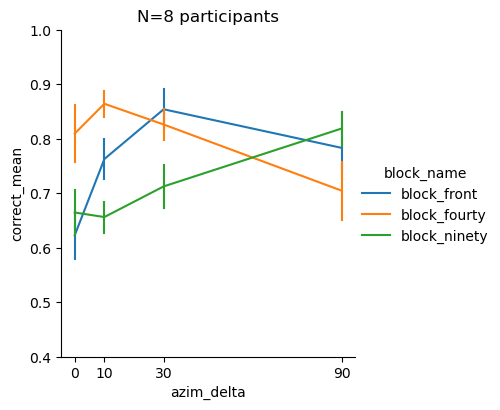

In [26]:
hue_order = ['block_front', 'block_fourty', 'block_ninety']
N = results_summary.participant.nunique()
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=4,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))
plt.title(f"N={N} participants")

Text(0.5, 1.0, 'N=8 participants')

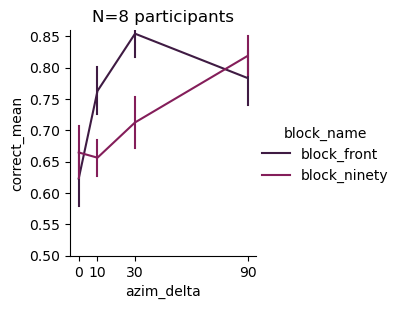

In [38]:
hue_order = ['block_front', 'block_fourty', 'block_ninety']
hue_order = ['block_front',  'block_ninety']
N = results_summary.participant.nunique()
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate(['block_front', 'block_ninety'])}


g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=3,
                palette=palette,
                kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.5, .86, 0.05), ylim=(0.5, 0.86))
plt.title(f"N={N} participants")

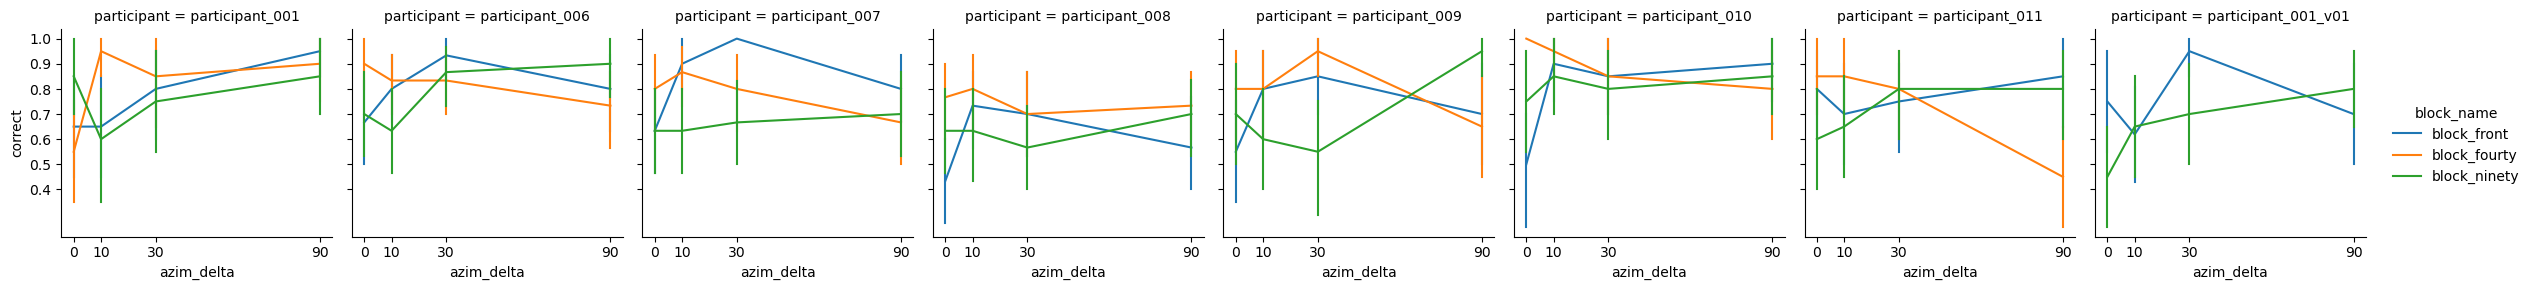

In [39]:
hue_order = ['block_front', 'block_fourty', 'block_ninety']
g = sns.relplot(data=results_df, x='azim_delta', y='correct',
                 hue='block_name',hue_order=hue_order,
                err_style='bars',
                 col='participant',
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

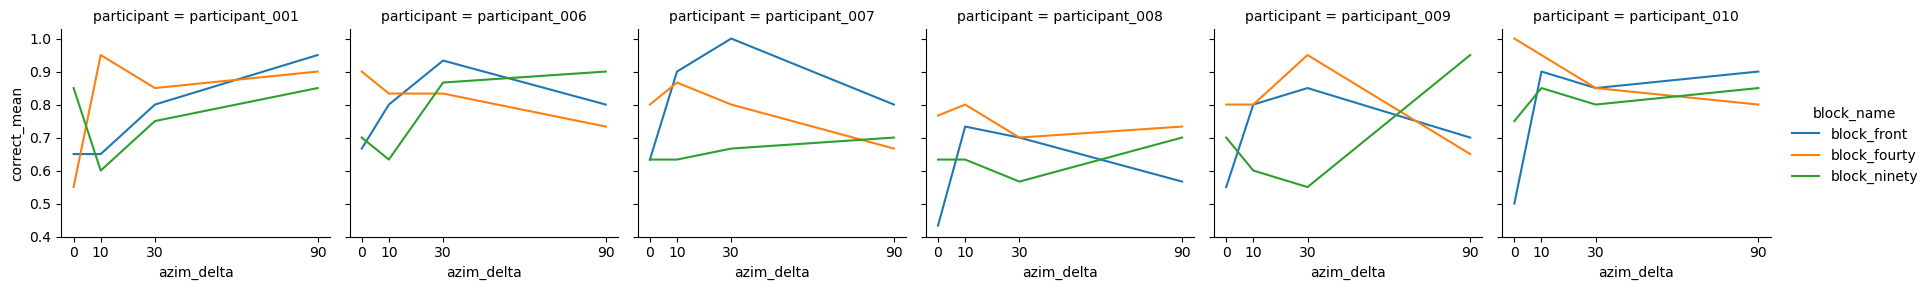

In [9]:
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                err_style='bars',
                 col='participant',
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

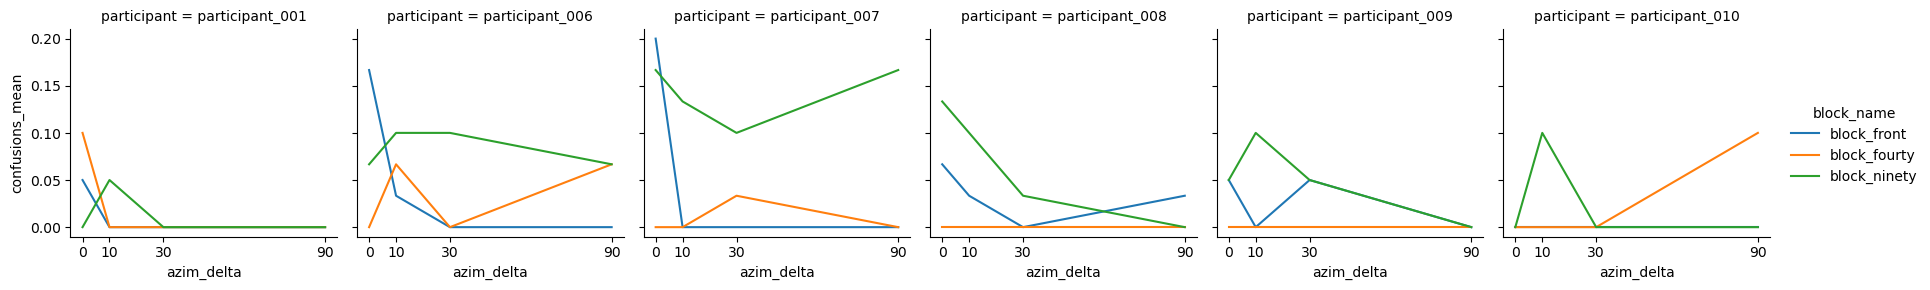

In [10]:
g = sns.relplot(data=results_summary, x='azim_delta', y='confusions_mean', 
                hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                 col='participant',
                 height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique())

In [106]:
SNRs = [0]

def draw_block_spotlight(distractor_side, target_azim):
    distractor_deltas = [0, 10, 30, 90] # use same as azimuth 
    # snrs = [0, -3, -6, -9]
    # return tuples of (target_loc, distractor_locs, azim_delta, elev_delta. snr)
    trials = []
    for delta in distractor_deltas:
      # calc elevation delta relative to most extreme position
      if distractor_side == 'right':
        if target_azim == 40:
          target_azim = -40 # flip dir and move distractors to right 
        dist_azim = target_azim + delta 
      elif distractor_side == 'left':
        if target_azim == 40:
          target_azim = 40 # flip dir and move distractors to right 
        dist_azim = target_azim - delta 
        
      trial = {'target_loc':(target_azim, 0),
               'distractor_loc':(dist_azim, 0),
               'azim_delta':delta,
               'elev_delta':0,
               'snr':0}
      
      trials.append(trial)
    return trials
  

In [138]:
import random

def sample_df(df, group, cond1, cond2, n):
	df_1 = df[df[f'{group}'] == cond1]
	df_2 = df[df[f'{group}'] == cond2]
	df_1_sample = df_1.sample(n=n)
	df_2_sample = df_2[~df_2.word.isin(df_1_sample.word)].sample(n=n)
    # keep original ixs to track metadata in analysis scripts 
	df_1_sample = df_1_sample.reset_index()
	df_1_sample.rename(columns={'index':'full_df_index'}, inplace=True)
	df_2_sample = df_2_sample.reset_index()
	df_2_sample.rename(columns={'index':'full_df_index'}, inplace=True)
	return pd.concat([df_1_sample, df_2_sample], axis=0, ignore_index=True)

def get_subset_df(df, n_words=480):
	n_to_samp = n_words // 4
	female_df = sample_df(df[df.gender == 'female'], 'sex_cond', 'same', 'different',n_to_samp)
	male_df = sample_df(df[(df.gender == 'male') & (~df.word.isin(female_df.word))], 'sex_cond', 'same', 'different', n_to_samp)
	return pd.concat([female_df, male_df], axis=0, ignore_index=True)



n_blocks_per_condition = 2 
num_trials_per_condition = 25
n_per_block = num_trials_per_condition // n_blocks_per_condition
print(n_per_block)

dist_side = 'left'
n_total_trials = 0 
experiment = {}
for block_num in range(n_blocks_per_condition):
    for target_loc in [0, 40, 90]:
        block = []
        block_str = f"target_{target_loc}_block_{block_num+1}"
        for trial_num in range(n_per_block):
            if target_loc == 90:
                block.extend(draw_block_spotlight(dist_side, 0))
            else:
                block.extend(draw_block_spotlight(dist_side, target_loc))
        n_total_trials += len(block)
        random.shuffle(block)
        experiment[block_str] = block

# experiment['target_40_block_1']
print(n_total_trials)

## Get speech excerpts 

to_sample = manifest[~manifest.client_id.str.contains('bowie|1906-cc|laurahale')]
participant_trial_stim_df = get_subset_df(to_sample, n_words=n_total_trials).sample(frac=1.0).reset_index(drop=True)

global_trial_ix = 0 
for block_name, trials in experiment.items():
    for i, trial in enumerate(trials):
        trial['cue_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_cue_src_fn'].split('/')[-1]
        trial['target_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_src_fn'].split('/')[-1]
        trial['distractor_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_distractor_1_src_fn'].split('/')[-1]
        trial['distractor_word'] = participant_trial_stim_df.loc[global_trial_ix, 'distractor_word'][0]
        trial['global_trial_ix'] = global_trial_ix
        trial['block_ix'] = i
        global_trial_ix += 1
        

12
288
